# 01 — E-waste dataset EDA

Run from the repo root (`uv run jupyter lab notebooks/01_eda.ipynb`), so relative
paths to `__data__/` and `src/` resolve.

In [ ]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
import pandas as pd

from src.models.data_loader import load_data
from src.models.schema import CARBON_TARGET, CATEGORICAL_FEATURES, NUMERIC_FEATURES, TARGET

df = load_data(os.path.join("__data__", "slm_synthetic_dataset_corrected.csv"))
df.shape

(7500, 16)

## Columns, types, missing values

In [2]:
pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulls": df.isna().sum(),
    "unique": df.nunique(),
})

,dtype,nulls,unique
user_name,str,0,1493
weight_of_waste_grams,float64,0,7444
number_of_ewaste_devices,int64,0,9
ewaste_scrap_image_ref,str,0,7500
material_category,str,0,8
price_valuation_inr,float64,0,7388
price_trend,str,0,3
nearby_recycler_id,str,0,60
reference_id,str,0,7500
mode_of_transaction,str,0,2


## Targets and numeric features

In [3]:
df[NUMERIC_FEATURES + [TARGET]].describe().T

,count,mean,std,min,25%,50%,75%,max
weight_of_waste_grams,7500.0,28386.713547,26936.404982,151.80,6902.3750,14127.05,49771.0250,89983.30
number_of_ewaste_devices,7500.0,2.015067,2.749566,0.00,0.0000,0.00,4.0000,8.00
estimated_carbon_emission_grams,7500.0,45127.512067,45729.300533,179.20,11338.5250,28899.05,65495.5250,242440.00
price_valuation_inr,7500.0,4055.550656,10935.012738,7.49,398.3625,826.98,1447.4825,65386.37


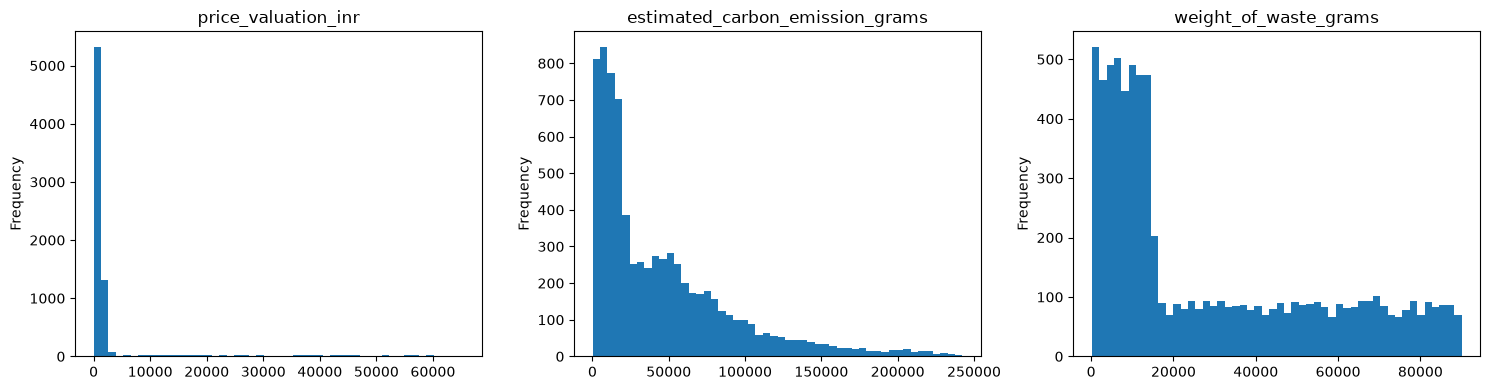

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, [TARGET, CARBON_TARGET, "weight_of_waste_grams"]):
    df[col].plot.hist(bins=50, ax=ax, title=col)
plt.tight_layout()

## Categorical levels

These are the exact strings the API accepts.

In [5]:
for col in CATEGORICAL_FEATURES:
    print(col, "->", sorted(df[col].unique()))

material_category -> ['Copper', 'E-Waste PCB', 'Hard Plastics', 'Iron / Steel', 'Lead-Acid Battery', 'Newspaper', 'PET Bottles', 'Small Battery']
price_trend -> ['Falling', 'Rising', 'Stable']
mode_of_transaction -> ['Cash', 'UPI']
recycler_location -> ['Ankleshwar, Gujarat', 'Bhiwandi, Maharashtra', 'Dharavi, Mumbai', 'Guindy, Chennai', 'Jamshedpur, Jharkhand', 'Kanpur, Uttar Pradesh', 'Ludhiana, Punjab', 'Mayapuri Industrial Area, Delhi', 'Narela, New Delhi', 'Okhla Phase 2, New Delhi', 'Peenya, Bengaluru', 'Sanathnagar, Hyderabad']
authorization_status -> ['Authorized', 'Pending Verification']


## What drives price and carbon

In [6]:
df[NUMERIC_FEATURES + [TARGET]].corr()[[TARGET, CARBON_TARGET]]

,price_valuation_inr,estimated_carbon_emission_grams
weight_of_waste_grams,0.378947,0.855145
number_of_ewaste_devices,-0.223028,-0.461424
estimated_carbon_emission_grams,0.709267,1.000000
price_valuation_inr,1.000000,0.709267


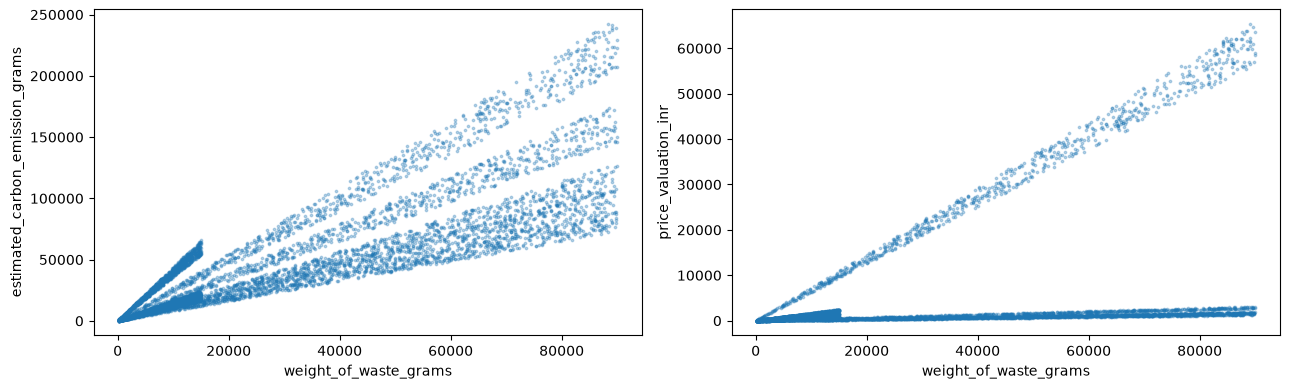

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df.plot.scatter(x="weight_of_waste_grams", y=CARBON_TARGET, s=3, alpha=0.3, ax=axes[0])
df.plot.scatter(x="weight_of_waste_grams", y=TARGET, s=3, alpha=0.3, ax=axes[1])
plt.tight_layout()

In [8]:
df.groupby("material_category")[[TARGET, CARBON_TARGET, "weight_of_waste_grams"]].median().sort_values(TARGET)

,price_valuation_inr,estimated_carbon_emission_grams,weight_of_waste_grams
material_category,,,
Small Battery,366.885,10996.10,7407.65
PET Bottles,653.480,48257.65,44036.05
Lead-Acid Battery,686.665,8760.85,7207.30
Hard Plastics,849.575,55403.50,42905.60
Newspaper,853.720,42487.20,47919.10
E-Waste PCB,1114.675,30028.50,7553.05
Iron / Steel,1477.060,82667.50,46034.50
Copper,28831.990,103593.20,43011.70


### Takeaways

- Weight dominates both targets; material category shifts the per-gram rate.
- Carbon is close to a function of weight and category — hence the separate carbon model
  that never sees the carbon column (see `src/models/schema.py::TASKS`).